=== BASELINE MULTINOMIAL NAIVE BAYES ===
Accuracy: 0.8058
F1 Score: 0.8374
Runtime: 0.07 seconds
--------------------------------------------------
--- Tuning Parameter Set 1 ---
Best Params: {'alpha': 0.5}
Accuracy: 0.8398, F1 Score: 0.8596, Runtime: 2.64s

--- Tuning Parameter Set 2 ---
Best Params: {'alpha': 1.0}
Accuracy: 0.8058, F1 Score: 0.8374, Runtime: 0.64s

--- Tuning Parameter Set 3 ---
Best Params: {'alpha': 0.25}
Accuracy: 0.8204, F1 Score: 0.8398, Runtime: 0.78s



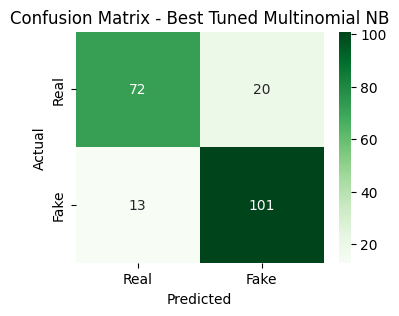


=== MULTINOMIAL NAIVE BAYES MODEL COMPARISON ===
        Set      Best Params  Accuracy  F1 Score  Runtime (s)
0  Baseline          Default    0.8058    0.8374         0.07
1         1   {'alpha': 0.5}    0.8398    0.8596         2.64
2         2   {'alpha': 1.0}    0.8058    0.8374         0.64
3         3  {'alpha': 0.25}    0.8204    0.8398         0.78

=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===
[0.83157895 0.86153846 0.83417085 0.87234043 0.83516484]
Mean CV F1 Score: 0.847


In [1]:
# MODEL 6: MULTINOMIAL NAIVE BAYES

import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("final_preprocessed_vectorized.csv")

# Features and target
tfidf_cols = [c for c in df.columns if c.startswith('tfidf_')]
X = df[tfidf_cols]
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline Multinomial Naive Bayes
mnb_base = MultinomialNB()
start = time.time()
mnb_base.fit(X_train, y_train)
yp_base = mnb_base.predict(X_test)
end = time.time()
baseline_runtime = round(end - start, 2)

print("=== BASELINE MULTINOMIAL NAIVE BAYES ===")
print("Accuracy:", round(accuracy_score(y_test, yp_base),4))
print("F1 Score:", round(f1_score(y_test, yp_base),4))
print("Runtime:", baseline_runtime, "seconds")
print("-"*50)

#  Parameter tuning with three different sets
param_sets = [
    {'alpha':[0.1,0.5]},
    {'alpha':[1.0,2.0]},
    {'alpha':[0.25,0.75,1.5]}
]

best_score = 0
best_model = None
best_params = None
tuning_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for i, params in enumerate(param_sets, 1):
    print(f"--- Tuning Parameter Set {i} ---")
    mnb_model = MultinomialNB()

    start = time.time()
    grid = GridSearchCV(mnb_model, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    end = time.time()
    runtime = round(end - start, 2)

    yp = grid.predict(X_test)
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp)

    tuning_results.append({
        'Set': i,
        'Best Params': grid.best_params_,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4),
        'Runtime (s)': runtime
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {round(acc,4)}, F1 Score: {round(f1,4)}, Runtime: {runtime}s\n")

    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_params = grid.best_params_

#  Confusion Matrix for Best Tuned Model
yp_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("Confusion Matrix - Best Tuned Multinomial NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison Table
comparison_df = pd.DataFrame(tuning_results)
baseline_row = pd.DataFrame([{
    'Set': 'Baseline',
    'Best Params': 'Default',
    'Accuracy': round(accuracy_score(y_test, yp_base),4),
    'F1 Score': round(f1_score(y_test, yp_base),4),
    'Runtime (s)': baseline_runtime
}])
comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print("\n=== MULTINOMIAL NAIVE BAYES MODEL COMPARISON ===")
print(comparison_df)

#  Cross-validation on Best Tuned Model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
print("\n=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===")
print(cv_scores)
print("Mean CV F1 Score:", round(np.mean(cv_scores),4))
